## Import Libs

In [10]:
import pandas as pd
import numpy as np

import os
import sys

# librosa is a Python library for analyzing audio and music. It can be used to extract the data from the audio files we will see it later.
import librosa
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# to play the audio files
from IPython.display import Audio

import keras
from keras.callbacks import ReduceLROnPlateau
from keras.models import Sequential
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization
from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint

## Load CREMA dataset

In [11]:
# Load the audio dataset
import os
import re

def load_audio_dataset(audio_dir="../../data/AudioWAV/"):
    """
    Load the audio dataset from the CREMA dataset directory.
    
    Args:
        audio_dir (str): Path to the audio directory
        
    Returns:
        pd.DataFrame: DataFrame containing audio file information
    """
    emotions = []
    intensities = []
    actors = []
    series_types = []
    filenames = []
    
    # Define emotion mapping
    emotion_map = {
        'ANG': 'angry',
        'DIS': 'disgusted', 
        'FEA': 'fearful',
        'HAP': 'happy',
        'NEU': 'neutral',
        'SAD': 'sad'
    }
    
    # Intensity mapping for IEO files (only IEO series has explicit intensity levels)
    intensity_map = {
        'HI': 'high',
        'MD': 'medium', 
        'LO': 'low'
    }
    
    # All valid series types in the dataset
    valid_series = ['DFA', 'IEO', 'IOM', 'ITH', 'ITS', 'IWL', 'IWW', 'MTI', 'TAI', 'TIE', 'TSI', 'WSI']
    
    # Check if the directory exists
    if not os.path.exists(audio_dir):
        raise FileNotFoundError(f"Audio directory not found: {audio_dir}")
    
    print(f"Loading audio files from: {audio_dir}")
    
    for filename in os.listdir(audio_dir):
        if filename.endswith('.wav'):
            # Parse filename to extract information
            # Format: {ID}_{SERIES}_{EMOTION}_{LEVEL/XX}.wav
            parts = filename.replace('.wav', '').split('_')
            
            if len(parts) >= 4:
                actor_id = parts[0]
                series = parts[1]  # DFA, IEO, ITS, IOM, etc.
                emotion_code = parts[2]
                
                # Only process valid series types and emotion codes
                if series in valid_series and emotion_code in emotion_map:
                    emotion = emotion_map[emotion_code]
                    
                    # Determine intensity level
                    intensity = 'medium'  # default intensity for non-IEO series
                    
                    # Only IEO series has explicit intensity levels (HI, MD, LO)
                    if series == 'IEO' and len(parts) >= 4:
                        intensity_code = parts[3]
                        if intensity_code in intensity_map:
                            intensity = intensity_map[intensity_code]
                    
                    emotions.append(emotion)
                    intensities.append(intensity)
                    actors.append(int(actor_id))
                    series_types.append(series)
                    filenames.append(filename)  # Store only filename, not full path
    
    # Create DataFrame without file_path column
    df = pd.DataFrame({
        'filename': filenames,
        'emotion': emotions,
        'intensity': intensities,
        'actor_id': actors,
        'series': series_types
    })
    
    return df

# Load the dataset
try:
    audio_df = load_audio_dataset()
    
    print(f"\nDataset loaded successfully!")
    print(f"Total audio files: {len(audio_df)}")
    print(f"\nDataset shape: {audio_df.shape}")
    print(f"\nFirst 10 rows:")
    print(audio_df.head(10))
    
    print(f"\nEmotion distribution:")
    print(audio_df['emotion'].value_counts())
    
    print(f"\nIntensity distribution:")
    print(audio_df['intensity'].value_counts())
    
    print(f"\nSeries distribution:")
    print(audio_df['series'].value_counts())
    
    print(f"\nNumber of unique actors: {audio_df['actor_id'].nunique()}")
    
    # Display some statistics
    print(f"\nDataset Statistics:")
    print(f"- Audio files: {len(audio_df)}")
    print(f"- Emotions: {audio_df['emotion'].nunique()} ({', '.join(audio_df['emotion'].unique())})")
    print(f"- Actors: {audio_df['actor_id'].nunique()}")
    print(f"- Series types: {audio_df['series'].nunique()} ({', '.join(audio_df['series'].unique())})")
    
    # Check for any missing values
    print(f"\nMissing values:")
    print(audio_df.isnull().sum())
    
except FileNotFoundError as e:
    print(f"Error: {e}")
    print("\nTrying alternative paths...")
    
    # Try alternative paths
    alternative_paths = [
        "../../../data/AudioWAV/",
        "/Users/sagarpratapsingh/dev/sagerstack/ml-speech-emotion-recognition/data/AudioWAV/",
        os.path.join(os.getcwd(), "../../data/AudioWAV/")
    ]
    
    for path in alternative_paths:
        if os.path.exists(path):
            print(f"Found audio directory at: {path}")
            print(f"Update the audio_dir parameter to: '{path}'")
            break
    else:
        print("Could not find the audio directory. Please check the path.")

Loading audio files from: ../../data/AudioWAV/

Dataset loaded successfully!
Total audio files: 7442

Dataset shape: (7442, 5)

First 10 rows:
              filename    emotion intensity  actor_id series
0  1022_ITS_ANG_XX.wav      angry    medium      1022    ITS
1  1037_ITS_ANG_XX.wav      angry    medium      1037    ITS
2  1060_ITS_NEU_XX.wav    neutral    medium      1060    ITS
3  1075_ITS_NEU_XX.wav    neutral    medium      1075    ITS
4  1073_IOM_DIS_XX.wav  disgusted    medium      1073    IOM
5  1066_IOM_DIS_XX.wav  disgusted    medium      1066    IOM
6  1078_IWL_SAD_XX.wav        sad    medium      1078    IWL
7  1029_TAI_FEA_XX.wav    fearful    medium      1029    TAI
8  1039_IEO_SAD_MD.wav        sad    medium      1039    IEO
9  1008_TAI_HAP_XX.wav      happy    medium      1008    TAI

Emotion distribution:
emotion
angry        1271
disgusted    1271
sad          1271
fearful      1271
happy        1271
neutral      1087
Name: count, dtype: int64

Intensity distributi

## Data Visualization & Analysis

/var/folders/9j/rpjsxm596q352pwlqm6tpjyr0000gn/T/ipykernel_97968/3404870053.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=audio_df, x='emotion', palette='viridis')


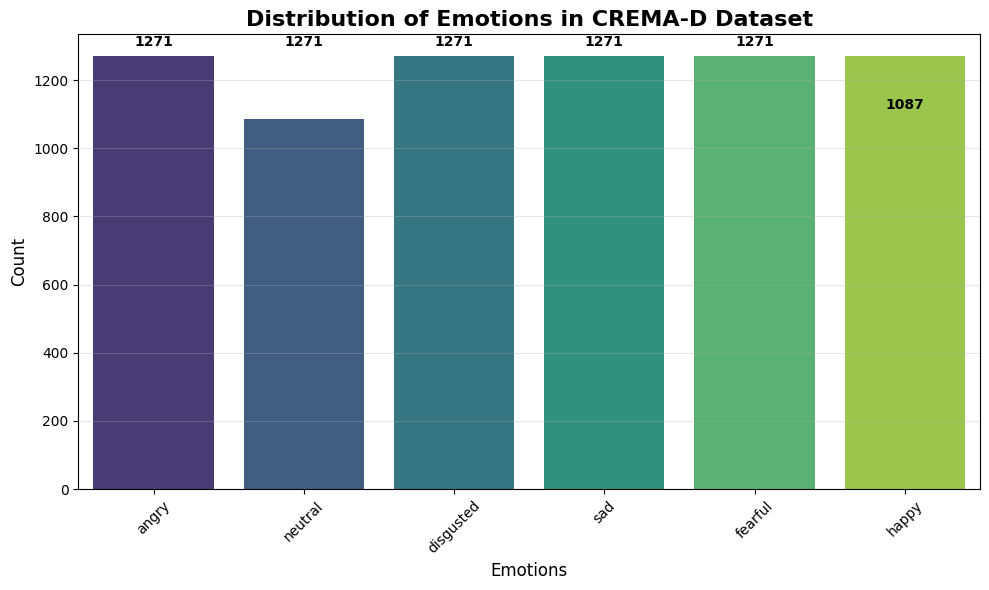

Emotion Distribution Statistics:
------------------------------
angry      : 1271 samples ( 17.1%)
disgusted  : 1271 samples ( 17.1%)
sad        : 1271 samples ( 17.1%)
fearful    : 1271 samples ( 17.1%)
happy      : 1271 samples ( 17.1%)
neutral    : 1087 samples ( 14.6%)

Total samples: 7442
Number of emotion categories: 6


In [12]:
# Count plot of emotions
plt.figure(figsize=(10, 6))
sns.countplot(data=audio_df, x='emotion', palette='viridis')
plt.title('Distribution of Emotions in CREMA-D Dataset', fontsize=16, fontweight='bold')
plt.xlabel('Emotions', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for i, count in enumerate(audio_df['emotion'].value_counts().values):
    plt.text(i, count + 20, str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print statistics
print("Emotion Distribution Statistics:")
print("-" * 30)
emotion_counts = audio_df['emotion'].value_counts()
for emotion, count in emotion_counts.items():
    percentage = (count / len(audio_df)) * 100
    print(f"{emotion:10} : {count:4} samples ({percentage:5.1f}%)")

print(f"\nTotal samples: {len(audio_df)}")
print(f"Number of emotion categories: {len(emotion_counts)}")

In [15]:
## Feature Extraction

In [16]:
# Load actor demographics data
def load_actor_demographics(demographics_path="../../data/ActorDemographics.csv"):
    """
    Load the actor demographics data from CREMA-D dataset.
    
    Args:
        demographics_path (str): Path to the ActorDemographics.csv file
        
    Returns:
        pd.DataFrame: DataFrame containing actor demographic information
    """
    try:
        demographics_df = pd.read_csv(demographics_path)
        print(f"Successfully loaded Actor Demographics!")
        print(f"Dataset shape: {demographics_df.shape}")
        return demographics_df
    except FileNotFoundError:
        print(f"Error: Could not find demographics file at {demographics_path}")
        
        # Try alternative paths
        alternative_paths = [
            "../../../data/ActorDemographics.csv",
            "/Users/sagarpratapsingh/dev/sagerstack/ml-speech-emotion-recognition/data/ActorDemographics.csv",
            os.path.join(os.getcwd(), "../../data/ActorDemographics.csv")
        ]
        
        for path in alternative_paths:
            if os.path.exists(path):
                print(f"Found demographics file at: {path}")
                try:
                    demographics_df = pd.read_csv(path)
                    print(f"Successfully loaded Actor Demographics!")
                    print(f"Dataset shape: {demographics_df.shape}")
                    return demographics_df
                except Exception as e:
                    print(f"Error loading file: {e}")
        
        print("Could not find the ActorDemographics.csv file. Please check the path.")
        return None

# Load the demographics dataset
actors_df = load_actor_demographics()

if actors_df is not None:
    print(f"\nFirst 10 rows of Actor Demographics:")
    print(actors_df.head(10))
    
    print(f"\nColumn names: {list(actors_df.columns)}")
    
    print(f"\nDemographics Summary:")
    print(f"- Total actors: {len(actors_df)}")
    print(f"- Age range: {actors_df['Age'].min()} to {actors_df['Age'].max()} years")
    print(f"- Gender distribution:")
    print(actors_df['Sex'].value_counts())
    print(f"- Race distribution:")
    print(actors_df['Race'].value_counts())
    print(f"- Ethnicity distribution:")
    print(actors_df['Ethnicity'].value_counts())
    
    print(f"\nMissing values:")
    print(actors_df.isnull().sum())
else:
    print("Failed to load actor demographics data.")

Successfully loaded Actor Demographics!
Dataset shape: (91, 5)

First 10 rows of Actor Demographics:
   ActorID  Age     Sex              Race     Ethnicity
0     1001   51    Male         Caucasian  Not Hispanic
1     1002   21  Female         Caucasian  Not Hispanic
2     1003   21  Female         Caucasian  Not Hispanic
3     1004   42  Female         Caucasian  Not Hispanic
4     1005   29    Male  African American  Not Hispanic
5     1006   58  Female         Caucasian  Not Hispanic
6     1007   38  Female  African American  Not Hispanic
7     1008   46  Female         Caucasian  Not Hispanic
8     1009   24  Female         Caucasian  Not Hispanic
9     1010   27  Female         Caucasian  Not Hispanic

Column names: ['ActorID', 'Age', 'Sex', 'Race', 'Ethnicity']

Demographics Summary:
- Total actors: 91
- Age range: 20 to 74 years
- Gender distribution:
Sex
Male      48
Female    43
Name: count, dtype: int64
- Race distribution:
Race
Caucasian           61
African American    22


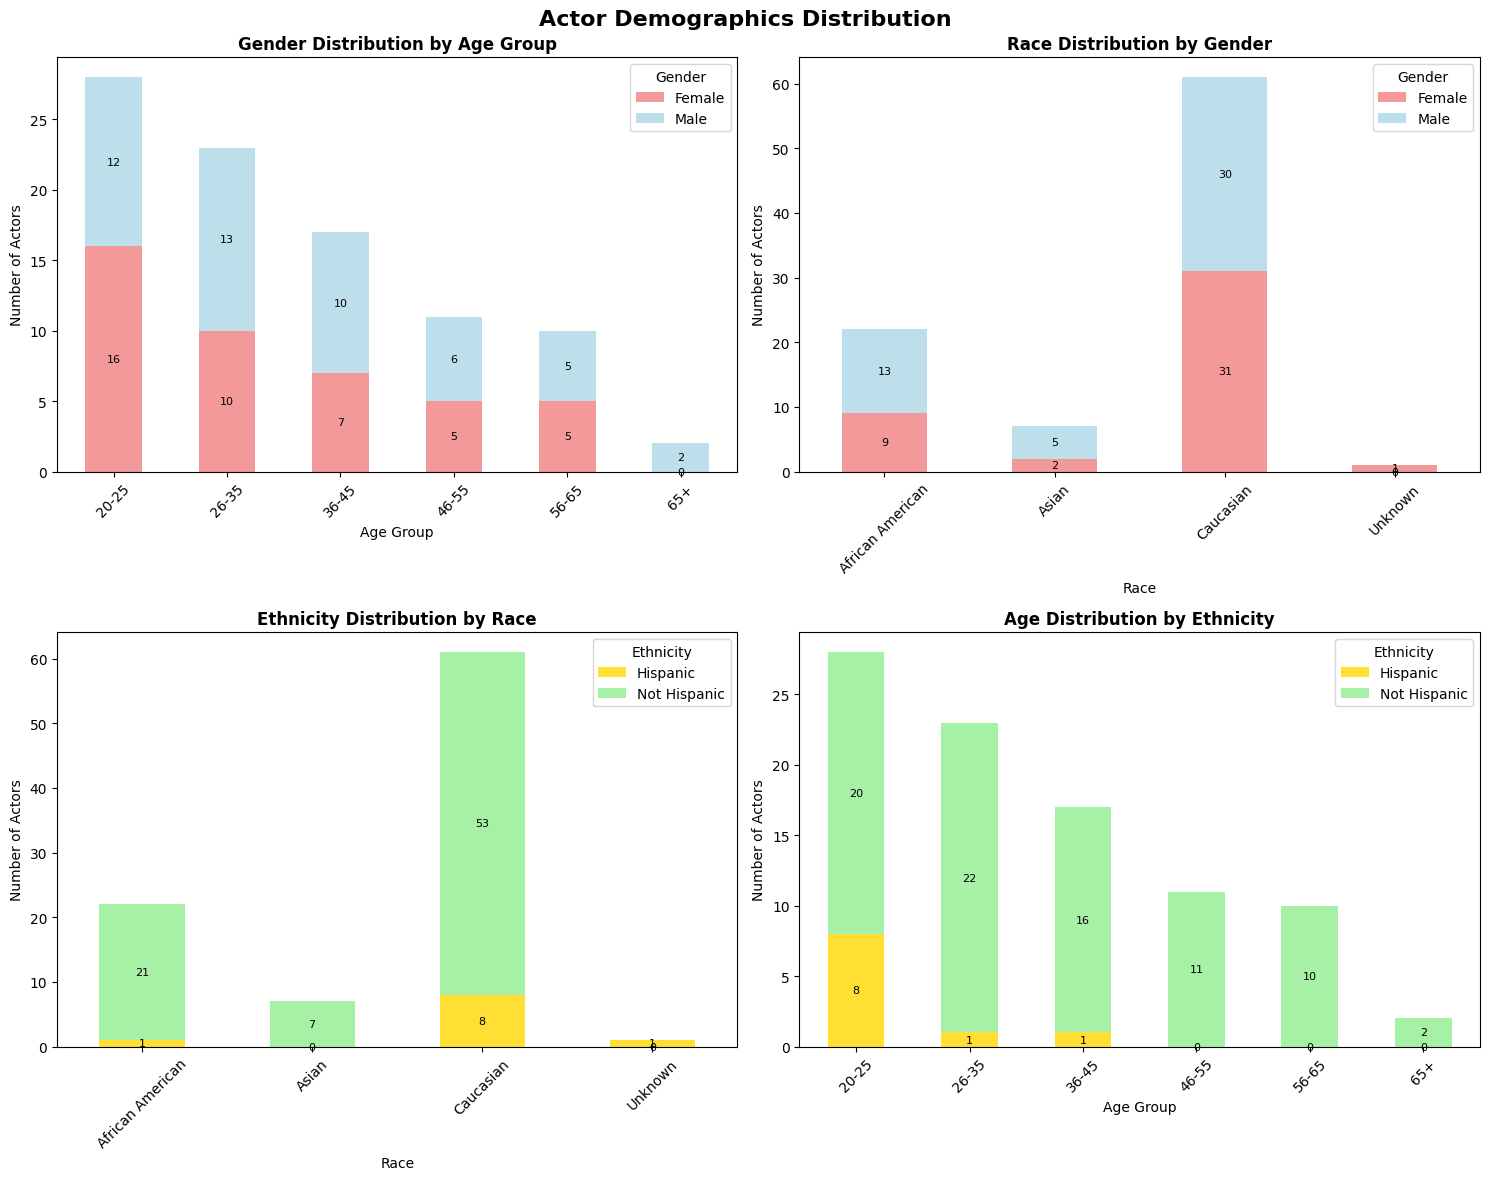


Detailed Actor Demographics Statistics:

1. Overall Statistics:
   Total Actors: 91
   Average Age: 36.4 years
   Median Age: 33.0 years

2. Gender Breakdown:
   Male       : 48 actors ( 52.7%)
   Female     : 43 actors ( 47.3%)

3. Race Breakdown:
   Caucasian       : 61 actors ( 67.0%)
   African American : 22 actors ( 24.2%)
   Asian           :  7 actors (  7.7%)
   Unknown         :  1 actors (  1.1%)

4. Ethnicity Breakdown:
   Not Hispanic    : 81 actors ( 89.0%)
   Hispanic        : 10 actors ( 11.0%)

5. Age Group Distribution:
   20-25      : 28 actors ( 30.8%)
   26-35      : 23 actors ( 25.3%)
   36-45      : 17 actors ( 18.7%)
   46-55      : 11 actors ( 12.1%)
   56-65      : 10 actors ( 11.0%)
   65+        :  2 actors (  2.2%)


In [17]:
# Actor Demographics Visualization - Stacked Bar Charts
if actors_df is not None:
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Actor Demographics Distribution', fontsize=16, fontweight='bold')
    
    # 1. Gender by Age Groups (Stacked Bar)
    actors_df_copy = actors_df.copy()
    actors_df_copy['Age_Group'] = pd.cut(actors_df_copy['Age'], 
                                       bins=[0, 25, 35, 45, 55, 65, 100], 
                                       labels=['20-25', '26-35', '36-45', '46-55', '56-65', '65+'])
    
    gender_age = pd.crosstab(actors_df_copy['Age_Group'], actors_df_copy['Sex'])
    gender_age.plot(kind='bar', stacked=True, ax=axes[0,0], 
                   color=['lightcoral', 'lightblue'], alpha=0.8)
    axes[0,0].set_title('Gender Distribution by Age Group', fontsize=12, fontweight='bold')
    axes[0,0].set_xlabel('Age Group', fontsize=10)
    axes[0,0].set_ylabel('Number of Actors', fontsize=10)
    axes[0,0].legend(title='Gender')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # Add value labels on stacked bars
    for c in axes[0,0].containers:
        axes[0,0].bar_label(c, label_type='center', fontsize=8)
    
    # 2. Race by Gender (Stacked Bar)
    race_gender = pd.crosstab(actors_df['Race'], actors_df['Sex'])
    race_gender.plot(kind='bar', stacked=True, ax=axes[0,1], 
                    color=['lightcoral', 'lightblue'], alpha=0.8)
    axes[0,1].set_title('Race Distribution by Gender', fontsize=12, fontweight='bold')
    axes[0,1].set_xlabel('Race', fontsize=10)
    axes[0,1].set_ylabel('Number of Actors', fontsize=10)
    axes[0,1].legend(title='Gender')
    axes[0,1].tick_params(axis='x', rotation=45)
    
    # Add value labels on stacked bars
    for c in axes[0,1].containers:
        axes[0,1].bar_label(c, label_type='center', fontsize=8)
    
    # 3. Ethnicity by Race (Stacked Bar)
    ethnicity_race = pd.crosstab(actors_df['Race'], actors_df['Ethnicity'])
    ethnicity_race.plot(kind='bar', stacked=True, ax=axes[1,0], 
                       color=['gold', 'lightgreen'], alpha=0.8)
    axes[1,0].set_title('Ethnicity Distribution by Race', fontsize=12, fontweight='bold')
    axes[1,0].set_xlabel('Race', fontsize=10)
    axes[1,0].set_ylabel('Number of Actors', fontsize=10)
    axes[1,0].legend(title='Ethnicity')
    axes[1,0].tick_params(axis='x', rotation=45)
    
    # Add value labels on stacked bars
    for c in axes[1,0].containers:
        axes[1,0].bar_label(c, label_type='center', fontsize=8)
    
    # 4. Age Distribution by Ethnicity (Stacked Bar)
    age_ethnicity = pd.crosstab(actors_df_copy['Age_Group'], actors_df['Ethnicity'])
    age_ethnicity.plot(kind='bar', stacked=True, ax=axes[1,1], 
                      color=['gold', 'lightgreen'], alpha=0.8)
    axes[1,1].set_title('Age Distribution by Ethnicity', fontsize=12, fontweight='bold')
    axes[1,1].set_xlabel('Age Group', fontsize=10)
    axes[1,1].set_ylabel('Number of Actors', fontsize=10)
    axes[1,1].legend(title='Ethnicity')
    axes[1,1].tick_params(axis='x', rotation=45)
    
    # Add value labels on stacked bars
    for c in axes[1,1].containers:
        axes[1,1].bar_label(c, label_type='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Additional statistics
    print("\nDetailed Actor Demographics Statistics:")
    print("=" * 50)
    
    print(f"\n1. Overall Statistics:")
    print(f"   Total Actors: {len(actors_df)}")
    print(f"   Average Age: {actors_df['Age'].mean():.1f} years")
    print(f"   Median Age: {actors_df['Age'].median()} years")
    
    print(f"\n2. Gender Breakdown:")
    gender_counts = actors_df['Sex'].value_counts()
    for gender, count in gender_counts.items():
        percentage = (count / len(actors_df)) * 100
        print(f"   {gender:10} : {count:2} actors ({percentage:5.1f}%)")
    
    print(f"\n3. Race Breakdown:")
    race_counts = actors_df['Race'].value_counts()
    for race, count in race_counts.items():
        percentage = (count / len(actors_df)) * 100
        print(f"   {race:15} : {count:2} actors ({percentage:5.1f}%)")
    
    print(f"\n4. Ethnicity Breakdown:")
    ethnicity_counts = actors_df['Ethnicity'].value_counts()
    for ethnicity, count in ethnicity_counts.items():
        percentage = (count / len(actors_df)) * 100
        print(f"   {ethnicity:15} : {count:2} actors ({percentage:5.1f}%)")
    
    print(f"\n5. Age Group Distribution:")
    age_group_counts = actors_df_copy['Age_Group'].value_counts().sort_index()
    for age_group, count in age_group_counts.items():
        percentage = (count / len(actors_df)) * 100
        print(f"   {age_group:10} : {count:2} actors ({percentage:5.1f}%)")
    
else:
    print("Cannot create visualizations - actor demographics data not loaded.")

## Load ActorDemographics dataset